In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("../data/ApexPlanet_DataAnalytics_Raw_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [6]:
df.shape

(1000, 12)

In [8]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


## 1. Dataset Understanding

- Total records: 1000
- Total columns: 12
- Missing values found in Age and City.
- Order_Date is currently stored as string.
- Quantity is an integer column.
- Unit_Price and Total_Sales are numerical columns.
- Customer and product-related columns are stored as string.

In [10]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Order_ID             str
Order_Date           str
Customer_ID          str
Customer_Name        str
Age              float64
Gender               str
City                 str
Product              str
Category             str
Quantity           int64
Unit_Price       float64
Total_Sales      float64
dtype: object

In [13]:
df["Order_Date"].head()

0    2025-02-25
1    2025-10-14
2    2025-05-13
3    2025-12-02
4    2025-11-20
Name: Order_Date, dtype: str

In [15]:
#Date Conversion
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Order_Date"].dtype

dtype('<M8[us]')

In [52]:
df["Order_Date"].isnull().sum()

np.int64(0)

In [17]:
df["Age"].median()

np.float64(41.0)

In [19]:
#Missing Values Treatment: Age
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"].isnull().sum()

np.int64(0)

In [20]:
df["City"].mode()

0    Patna
Name: City, dtype: str

In [22]:
#Missing Values Treatment: City
df["City"]=df["City"].fillna(df["City"].mode()[0])
df["City"].isnull().sum()

np.int64(0)

In [23]:
df.isna().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

In [24]:
df.isnull().sum().sum()

np.int64(0)

In [25]:
df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].describe()

,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650
std,13.683626,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,53.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


***Exploratory Data Analysis***

In [48]:
# Numerical Data Summary
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683626,2.838632,14179.402361,114100.051546


In [47]:
# Unique Values in Each Column
df.nunique()

Order_ID          992
Order_Date        342
Customer_ID       947
Customer_Name     425
Age                48
Gender              2
City                8
Product             6
Category            5
Quantity           10
Unit_Price       1000
Total_Sales      1000
dtype: int64

In [46]:
# Category-wise Order Count
df["Category"].value_counts()

Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

In [45]:
# Product-wise Order Count
df["Product"].value_counts()

Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

In [44]:
# City-wise Order Count
df["City"].value_counts()

City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64

In [43]:
# Total Sales Analysis
df["Total_Sales"].agg(["sum", "mean", "min", "max"])

sum     1.393994e+08
mean    1.393994e+05
min     4.373400e+02
max     4.936775e+05
Name: Total_Sales, dtype: float64

In [40]:
# Total Quantity Sold
df["Quantity"].sum()

np.int64(5435)

In [39]:
# Category-wise Sales Analysis
category_sales = df.groupby("Category")["Total_Sales"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)
category_sales

,sum,mean,count
Category,,,
Electronics,50778581.70,143442.321186,354
Education,25031689.40,140627.468539,178
Grocery,22231711.28,145305.302484,153
Furniture,21521561.48,135355.732579,159
Fashion,19835895.79,127153.178141,156


In [38]:
# Product-wise Sales Analysis
product_sales = df.groupby("Product")["Total_Sales"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)
product_sales

,sum,mean,count
Product,,,
Laptop,25443008.51,149664.755941,170
Mobile,25335573.19,137693.332554,184
Book,25031689.40,140627.468539,178
Rice,22231711.28,145305.302484,153
Chair,21521561.48,135355.732579,159
Shoes,19835895.79,127153.178141,156


In [37]:
# City-wise Sales Analysis
city_sales = df.groupby("City")["Total_Sales"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)
city_sales

,sum,mean,count
City,,,
Patna,20826584.43,140720.165068,148
Kolkata,18884349.57,141987.590752,133
Bengaluru,18773574.32,153881.756721,122
Mumbai,18757050.17,143183.589084,131
Hyderabad,17166766.87,137334.134960,125
Delhi,16097079.00,128776.632000,125
Pune,14513175.90,146597.736364,99
Gaya,14380859.39,122913.328120,117


In [36]:
# Gender-wise Sales Analysis
gender_sales = df.groupby("Gender")["Total_Sales"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)
gender_sales

,sum,mean,count
Gender,,,
Male,72463550.63,141807.339785,511
Female,66935889.02,136883.208630,489


In [35]:
# Monthly Sales Analysis
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Total_Sales"].agg(
    ["sum", "mean", "count"]
)
monthly_sales

,sum,mean,count
Order_Date,,,
2025-01,10096190.73,132844.614868,76
2025-02,11511181.46,133850.947209,86
2025-03,13059899.94,146740.448764,89
2025-04,12222700.17,152783.752125,80
2025-05,10984689.25,129231.638235,85
2025-06,12912332.64,155570.272771,83
2025-07,11746226.80,141520.804819,83
2025-08,9448471.22,125979.616267,75
2025-09,9179896.29,116201.218861,79


***Visualization***

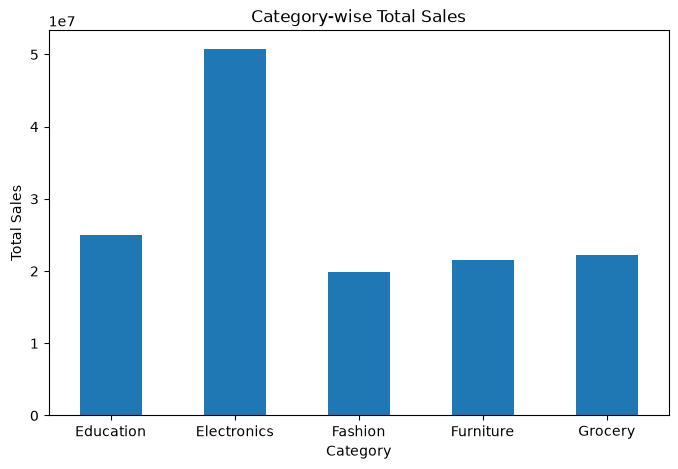

In [33]:
# Category-wise Sales Visualization
category_sales = df.groupby("Category")["Total_Sales"].sum()
category_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Category-wise Total Sales"
)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

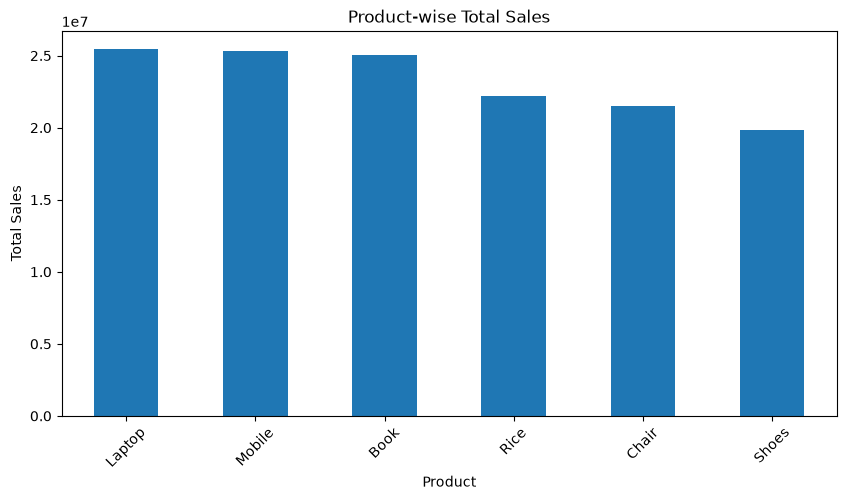

In [32]:
# Product-wise Sales Visualization 
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(
    ascending=False
)
product_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Product-wise Total Sales"
)
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

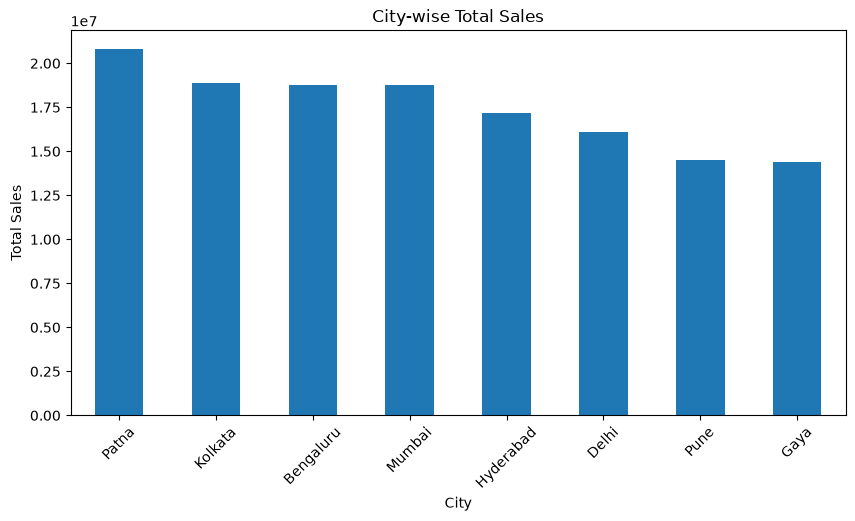

In [31]:
# City-wise Sales Visualization
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(
    ascending=False
)
city_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="City-wise Total Sales"
)
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

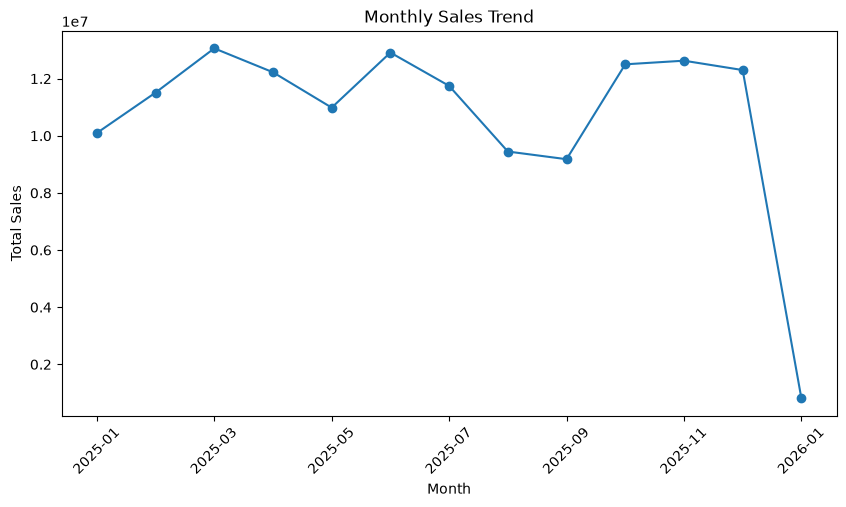

In [30]:
# Line Chart: Monthly Sales Trend
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Total_Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(
    kind="line",
    figsize=(10, 5),
    marker="o",
    title="Monthly Sales Trend"
)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

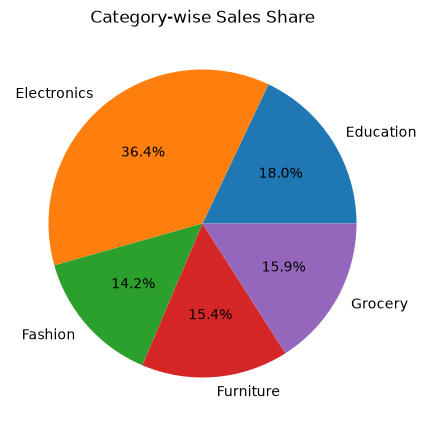

In [29]:
# Pie Chart: Category-wise Sales Share
category_sales = df.groupby("Category")["Total_Sales"].sum()
category_sales.plot(
    kind="pie",
    figsize=(8, 5),
    autopct="%1.1f%%",
    title="Category-wise Sales Share"
)
plt.ylabel("")
plt.show()

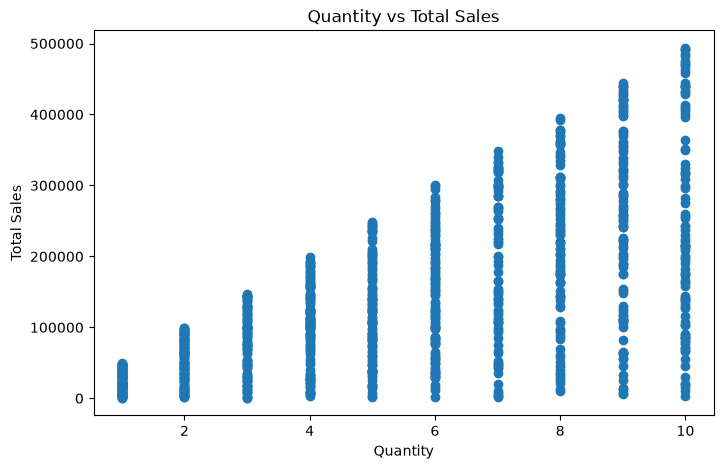

In [27]:
# Scatter Plot: Quantity vs Total Sales
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Quantity"],
    df["Total_Sales"]
)
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()

In [50]:
# Save Cleaned Dataset
df.to_csv("../data/cleaned_dataset.csv", index=False)

In [51]:
# Check Saved Dataset
import os
os.path.exists("../data/cleaned_dataset.csv")

True